In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv('loan_prediction_.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,Y
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,Y
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,Y
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,N
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(367, 13)

In [5]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
 12  Loan_Status        367 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 49.8 KB


In [7]:
df.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: >

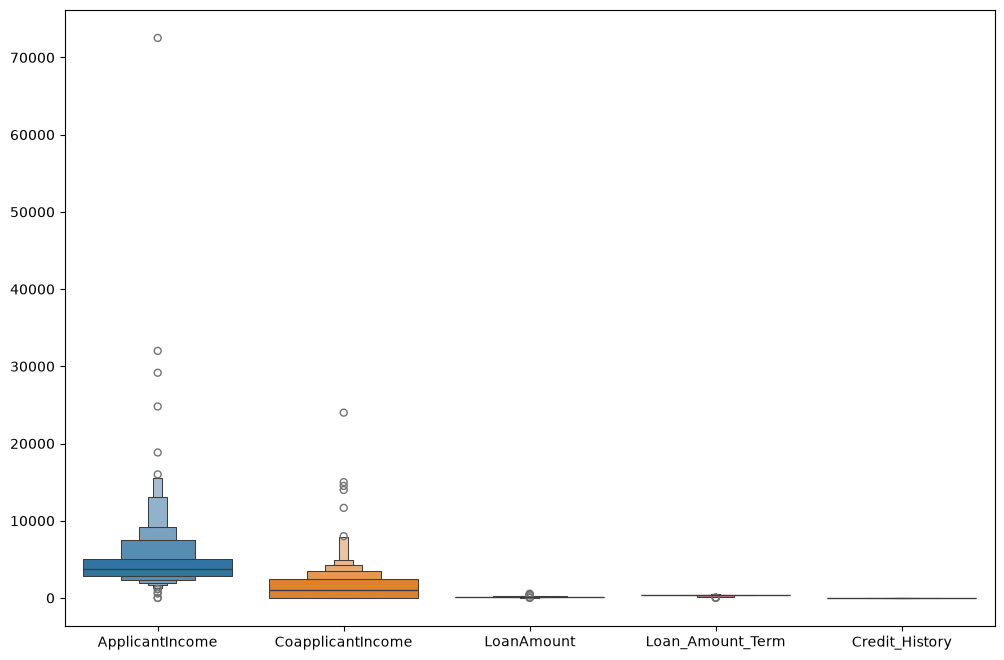

In [8]:
plt.figure(figsize=(12,8))
sns.boxenplot(data=df)

In [9]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())
# df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())



In [10]:
# df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())
# df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())
# df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())


In [11]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

In [12]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])


In [14]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Number of people who took loan by Gender
Gender
Male      297
Female     70
Name: count, dtype: int64


<Axes: xlabel='Gender', ylabel='count'>

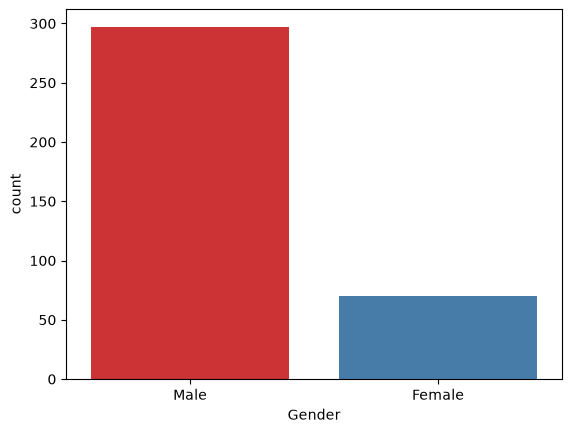

In [15]:
print('Number of people who took loan by Gender')
print(df['Gender'].value_counts())
sns.countplot(x = 'Gender', data=df, palette='Set1')

Number of people who took loan by Married
Married
Yes    233
No     134
Name: count, dtype: int64


<Axes: xlabel='Married', ylabel='count'>

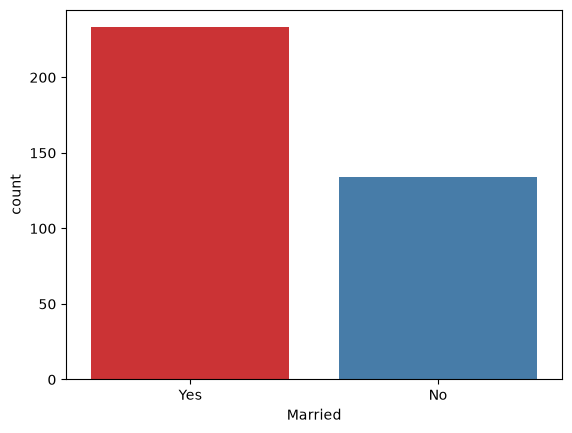

In [16]:
print('Number of people who took loan by Married')
print(df['Married'].value_counts())
sns.countplot(x = 'Married', data=df, palette='Set1')

Number of people who took loan by Education
Education
Graduate        283
Not Graduate     84
Name: count, dtype: int64


<Axes: xlabel='Education', ylabel='count'>

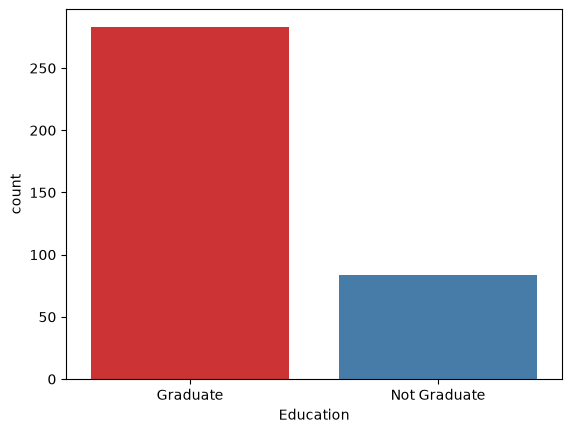

In [17]:
print('Number of people who took loan by Education')
print(df['Education'].value_counts())
sns.countplot(x = 'Education', data=df, palette='Set1')

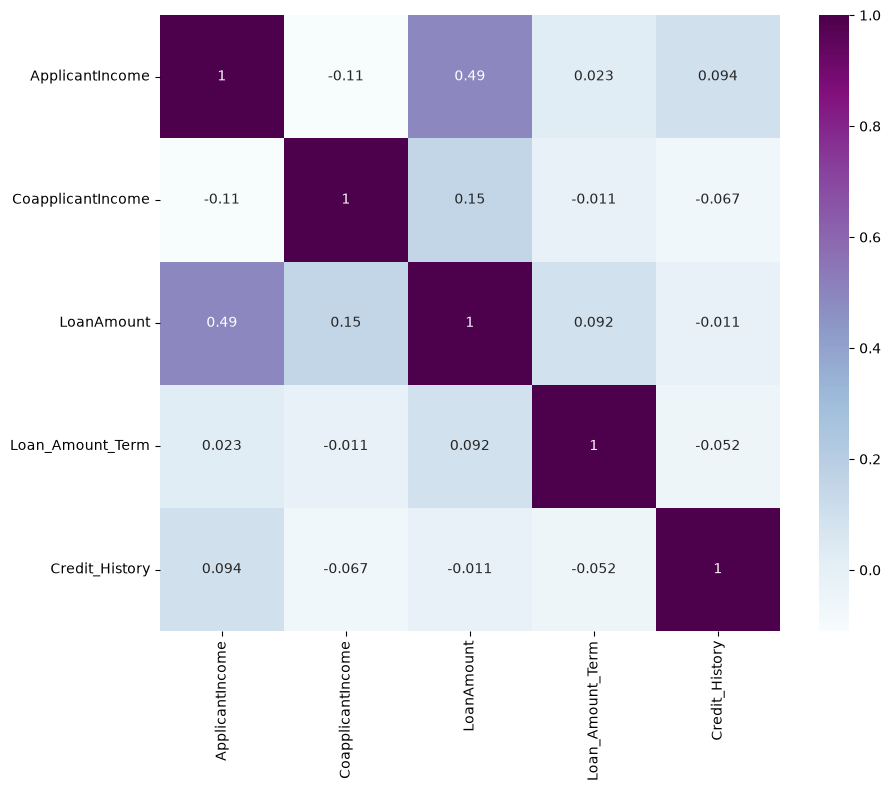

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='BuPu')
plt.show()

In [19]:
corr = df.select_dtypes(include='number').corr()
corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.110335,0.488737,0.023187,0.094083
CoapplicantIncome,-0.110335,1.000000,0.150034,-0.010940,-0.066798
LoanAmount,0.488737,0.150034,1.000000,0.092234,-0.011228
Loan_Amount_Term,0.023187,-0.010940,0.092234,1.000000,-0.052370
Credit_History,0.094083,-0.066798,-0.011228,-0.052370,1.000000


In [20]:
df['Total_Income'] = df['ApplicantIncome']+df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.000000,Urban,Y,5720
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.000000,Urban,Y,4576
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.000000,Urban,Y,6800
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,0.825444,Urban,N,4886
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.000000,Urban,Y,3276


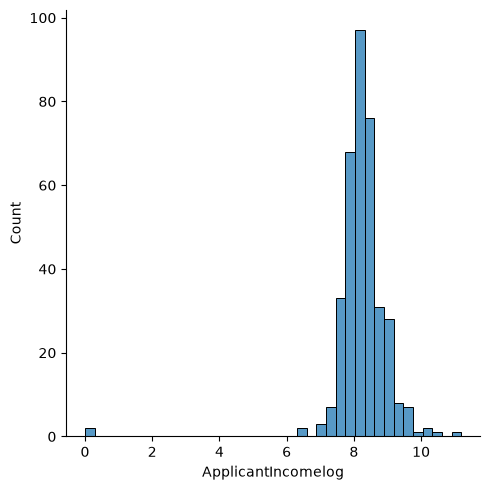

In [21]:
df['ApplicantIncomelog'] = np.log(df['ApplicantIncome']+1)
sns.displot(df['ApplicantIncomelog'])

In [22]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomelog
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.000000,Urban,Y,5720,8.651899
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.000000,Urban,Y,4576,8.031710
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.000000,Urban,Y,6800,8.517393
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,0.825444,Urban,N,4886,7.758333
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.000000,Urban,Y,3276,8.094684


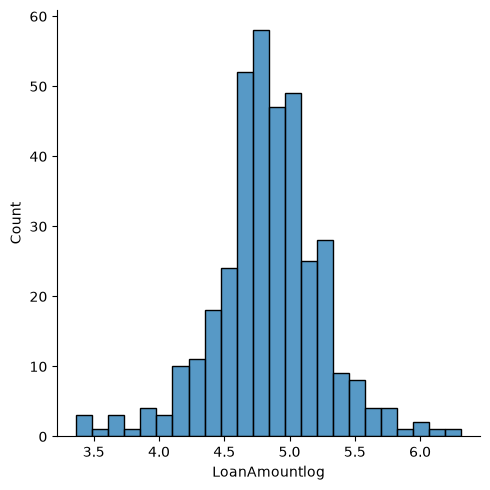

In [23]:
df['LoanAmountlog'] = np.log(df['LoanAmount']+1)
sns.displot(df['LoanAmountlog'])

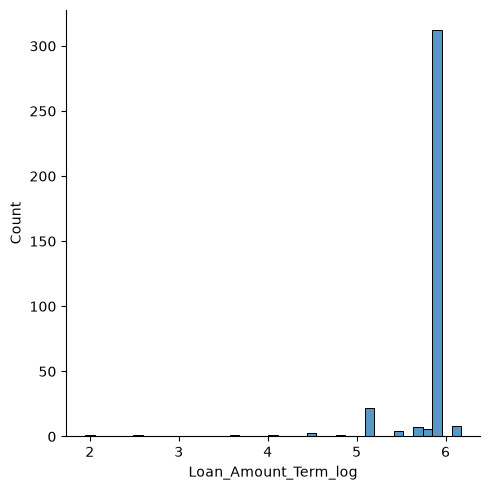

In [24]:
df['Loan_Amount_Term_log'] = np.log(df['Loan_Amount_Term']+1)
sns.displot(df['Loan_Amount_Term_log'])

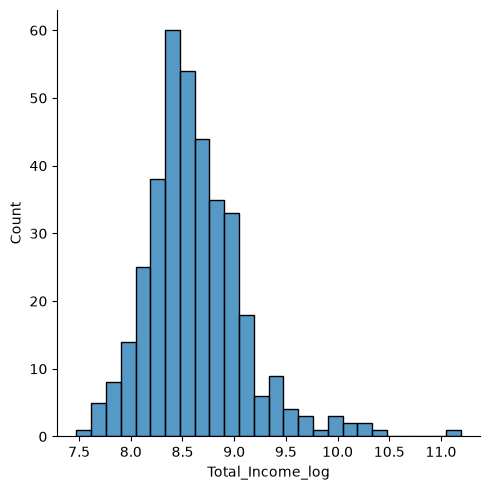

In [25]:
df['Total_Income_log'] = np.log(df['Total_Income']+1)
sns.displot(df['Total_Income_log'])

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.000000,Urban,Y,5720,8.651899,4.709530,5.888878,8.651899
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.000000,Urban,Y,4576,8.031710,4.844187,5.888878,8.428799
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.000000,Urban,Y,6800,8.517393,5.342334,5.888878,8.824825
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,0.825444,Urban,N,4886,7.758333,4.615121,5.888878,8.494334
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.000000,Urban,Y,3276,8.094684,4.369448,5.888878,8.094684


In [27]:
cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Total_Income', 'Loan_ID']

df = df.drop(columns=cols)

In [28]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,Male,Yes,0,Graduate,No,1.000000,Urban,Y,8.651899,4.709530,5.888878,8.651899
1,Male,Yes,1,Graduate,No,1.000000,Urban,Y,8.031710,4.844187,5.888878,8.428799
2,Male,Yes,2,Graduate,No,1.000000,Urban,Y,8.517393,5.342334,5.888878,8.824825
3,Male,Yes,2,Graduate,No,0.825444,Urban,N,7.758333,4.615121,5.888878,8.494334
4,Male,No,0,Not Graduate,No,1.000000,Urban,Y,8.094684,4.369448,5.888878,8.094684


In [29]:
from sklearn.preprocessing import LabelEncoder
cols=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status','Dependents']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

In [30]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,1,0,0,0,1.000000,2,1,8.651899,4.709530,5.888878,8.651899
1,1,1,1,0,0,1.000000,2,1,8.031710,4.844187,5.888878,8.428799
2,1,1,2,0,0,1.000000,2,1,8.517393,5.342334,5.888878,8.824825
3,1,1,2,0,0,0.825444,2,0,7.758333,4.615121,5.888878,8.494334
4,1,0,0,1,0,1.000000,2,1,8.094684,4.369448,5.888878,8.094684


In [31]:
df.dtypes 

Gender                    int64
Married                   int64
Dependents                int64
Education                 int64
Self_Employed             int64
Credit_History          float64
Property_Area             int64
Loan_Status               int64
ApplicantIncomelog      float64
LoanAmountlog           float64
Loan_Amount_Term_log    float64
Total_Income_log        float64
dtype: object

In [32]:
X = df.drop(columns='Loan_Status')
y = df['Loan_Status']

In [33]:
X

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,1,0,0,0,1.000000,2,8.651899,4.709530,5.888878,8.651899
1,1,1,1,0,0,1.000000,2,8.031710,4.844187,5.888878,8.428799
2,1,1,2,0,0,1.000000,2,8.517393,5.342334,5.888878,8.824825
3,1,1,2,0,0,0.825444,2,7.758333,4.615121,5.888878,8.494334
4,1,0,0,1,0,1.000000,2,8.094684,4.369448,5.888878,8.094684
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3,1,1,1.000000,2,8.296547,4.736198,5.888878,8.663369
363,1,1,0,0,0,1.000000,2,8.333030,4.753590,5.888878,8.490438
364,1,0,0,0,0,0.825444,1,8.086718,4.844187,5.888878,8.564840
365,1,1,0,0,0,1.000000,0,8.517393,5.068904,5.888878,8.908424


In [34]:
y

0      1
1      1
2      1
3      0
4      1
      ..
362    1
363    1
364    0
365    1
366    1
Name: Loan_Status, Length: 367, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [37]:
model1 = LogisticRegression()
model1.fit(X_train,y_train)
y_pred = model1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

In [38]:
accuracy

0.9324324324324325

In [39]:
import joblib

# Save the trained model
joblib.dump(model1, 'loan_model.pkl')

# Save the feature names and their order
joblib.dump(list(X.columns), 'loan_features.pkl')

print("Model saved successfully!")
print("Features saved successfully!")

Model saved successfully!
Features saved successfully!
